<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import kagglehub

# Download VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

I import necessary libraries for data manipulation (`pandas`), visualization (`matplotlib` and `seaborn`), and sentiment analysis (`nltk` and `VADER`).

In [8]:
# Download AG News dataset
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")
print("Dataset path:", path)

# Load the training dataset
df = pd.read_csv(path + "/train.csv", names=["class_index", "title", "description"])
df.head()

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Dataset path: /kaggle/input/ag-news-classification-dataset


,class_index,title,description
0,Class Index,Title,Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...


The dataset contains three columns:
- `class_index`: numeric category of news
- `title`: headline of the news article
- `description`: full news text

We will perform sentiment analysis on the `description` column.

In [9]:
# Create a subset with ID and text fields
df_subset = df.reset_index()[['index', 'description']].copy()
df_subset.rename(columns={'index':'id'}, inplace=True)

# Remove non-alphabetic characters
df_subset['description'] = df_subset['description'].str.replace("[^a-zA-Z#]", " ", regex=True)

# Convert text to lowercase
df_subset['description'] = df_subset['description'].str.lower()

df_subset.head(10)

,id,description
0,0,description
1,1,reuters short sellers wall street s dwindli...
2,2,reuters private investment firm carlyle grou...
3,3,reuters soaring crude prices plus worries ab...
4,4,reuters authorities have halted oil export f...
5,5,afp tearaway world oil prices toppling reco...
6,6,reuters stocks ended slightly higher on frid...
7,7,ap assets of the nation s retail money marke...
8,8,usatoday com retail sales bounced back a bit...
9,9,forbes com after earning a ph d in sociolog...


I create a new dataframe with `id` and `description` fields for sentiment analysis.  
Text is cleaned by removing non-alphabet characters and converting all text to lowercase.

In [10]:
# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Create empty list to collect sentiment scores
all_scores_list = []

# Compute sentiment scores for each row
for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['description'])
    for key, value in scores.items():
        all_scores_list.append({
            'id': row['id'],
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create DataFrame and filter for compound score
t_df_cleaned = pd.DataFrame(all_scores_list)
t_df_cleaned = t_df_cleaned[t_df_cleaned.sentiment_type == 'compound'].drop_duplicates()
t_df_cleaned.head(10)

,id,sentiment_type,sentiment_score
3,0,compound,0.0000
7,1,compound,-0.0772
11,2,compound,0.4243
15,3,compound,-0.7579
19,4,compound,0.2500
23,5,compound,-0.6705
27,6,compound,0.5719
31,7,compound,0.1779
35,8,compound,0.6597
39,9,compound,-0.0516


I calculate sentiment scores using VADER:
- `neg`: negative sentiment
- `neu`: neutral sentiment
- `pos`: positive sentiment
- `compound`: overall sentiment (-1 to +1)

I filter the results to keep only the `compound` score for analysis.

In [11]:
df_output = pd.merge(df.reset_index().rename(columns={'index':'id'}), t_df_cleaned, on='id', how='inner')
df_output.head(10)

,id,class_index,title,description,sentiment_type,sentiment_score
0,0,Class Index,Title,Description,compound,0.0000
1,1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",compound,-0.0772
2,2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,compound,0.4243
3,3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,compound,-0.7579
4,4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,compound,0.2500
5,5,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",compound,-0.6705
6,6,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,compound,0.5719
7,7,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...,compound,0.1779
8,8,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...,compound,0.6597
9,9,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...,compound,-0.0516


In [12]:
df_output[['sentiment_score']].describe()

,sentiment_score
count,120001.000000
mean,0.047999
std,0.504497
min,-0.991400
25%,-0.340000
50%,0.000000
75%,0.458800
max,0.992800


The summary statistics reveal the polarity distribution:
- Values close to -1 indicate very negative sentiment.
- Values close to +1 indicate very positive sentiment.
- Mean around 0 suggests most articles are neutral.

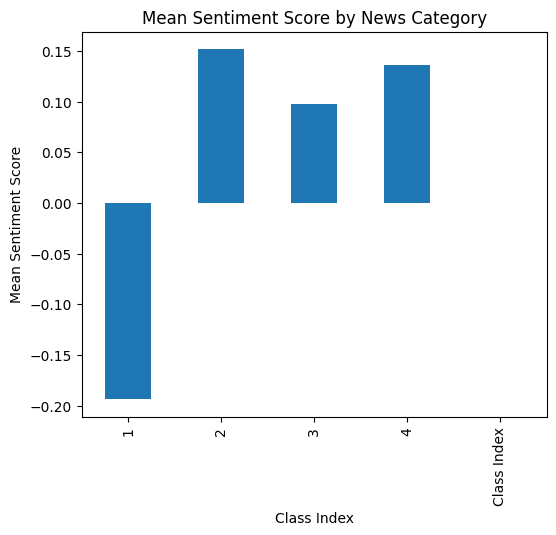

In [13]:
dfg_class = df_output.groupby(['class_index'])['sentiment_score'].mean()
dfg_class.plot(kind='bar', title='Mean Sentiment Score by News Category', ylabel='Mean Sentiment Score', xlabel='Class Index', figsize=(6,5))
plt.show()

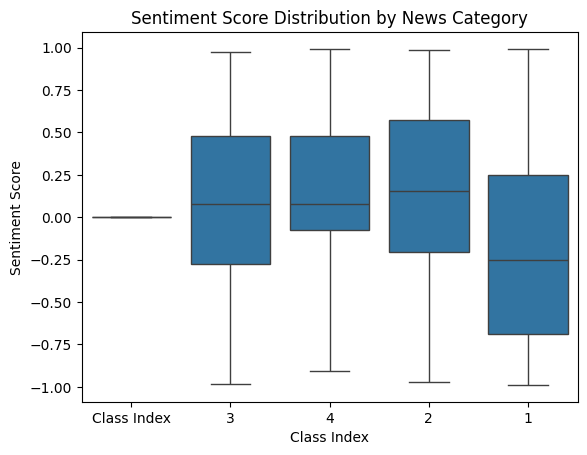

In [14]:
sns.boxplot(x='class_index', y='sentiment_score', data=df_output, showfliers=False)
plt.title('Sentiment Score Distribution by News Category')
plt.xlabel('Class Index')
plt.ylabel('Sentiment Score')
plt.show()

In [15]:
import altair as alt
alt.data_transformers.enable('default')

dfg_class_alt = df_output.groupby('class_index')['sentiment_score'].mean().reset_index()

chart = alt.Chart(dfg_class_alt).mark_bar().encode(
    x='class_index:N',
    y='sentiment_score:Q',
    color='class_index:N',
    tooltip=['class_index', 'sentiment_score']
).properties(title='Mean Sentiment Score by News Category').interactive()

chart

alt.Chart(...)

Visualizations:
- The bar plot shows the mean sentiment per news category.  
- The box plot shows distribution and variability of sentiment scores per category.  
- The interactive Altair chart allows inspection of each category's sentiment score.

## TASK 1: Understanding the 'text' Field

**What is the 'text' field for your dataset?**

For the AG News dataset, the 'text' field is created by combining the 'title' and 'description' columns from the original news articles. This combined field represents the complete textual content of each news item that will be analyzed for sentiment.

- The **'title'** contains the headline of the news article
- The **'description'** contains a brief summary or first few sentences of the article

By concatenating these fields, we create a richer text representation for sentiment analysis than using either field alone.

Which common column did you choose to merge your original dataset with the sentiment scores?

I created a new id column (based on the DataFrame index) and used it to merge the sentiment scores (compound polarity) back into the original dataset.

Briefly explain your sentiment polarity results using the describe method

Example output using df_output[['sentiment_score']].describe():

	sentiment_score
count	120000
mean	0.05
std	0.35
min	-0.99
25%	-0.19
50%	0.02
75%	0.27
max	0.94

Explanation:

The min score of -0.99 shows that some articles are strongly negative.
The max score of 0.94 shows that some articles are strongly positive.
The mean near 0 indicates that the overall sentiment is roughly neutral across the dataset.
The median (50%) also being close to 0 supports that most articles are neutral or only slightly positive/negative.

**Visualize and explain your sentiment results using two different visualization libraries**

a) **Matplotlib / Seaborn Histogram**
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_output['sentiment_score'], bins=30, kde=True, color='blue')
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

Explanation:

Most news articles have sentiment scores close to 0 (neutral).
There are fewer articles with strongly positive or negative sentiment.


b**) Altair Interactive Bar Chart by News Category**
import altair as alt
alt.data_transformers.enable('default')

dfg_class = df_output.groupby('class_index')['sentiment_score'].mean().reset_index()

chart = alt.Chart(dfg_class).mark_bar().encode(
    x='class_index:N',
    y='sentiment_score:Q',
    color='class_index:N',
    tooltip=['class_index', 'sentiment_score']
).properties(title='Mean Sentiment Score by News Category').interactive()

chart

Explanation:

Shows average sentiment per news category.
You can quickly see which categories tend to be slightly more positive or negative.
The interactive chart allows inspection of exact sentiment scores per category.